## Código de imposición de condiciones periódicas

El siguiente *notebook* presenta un código para la reducción del sistema inicial de la celda unitaria al imponer condiciones de periodicidad. Como referencia de la asociación de grados de libertad entre nodos se presenta la siguiente imagen:

<img src="./img/periodicConditionsFEM.png" width=640 align="middle">


<div class="alert alert-block alert-warning">
<b> Nota importante:</b> El código es adaptado a partir de las funciones adicionales para análisis de Bloch de la documentación de SolidSpy <a href="https://github.com/AppliedMechanics-EAFIT/SolidsPy/blob/master/solidspy/blochutil.py">que se encuentra aquí.</a>
</div>

### Funciones:

In [140]:
"""
Periodic Boundary Conditions utilities
------------------------

"""
import numpy as np
from scipy.sparse import coo_matrix

#%% Auxiliar
def reassign_dof_periodicBC(ndofs, dofs_ima, dofs_ref):
    """Find dof number after applying boundary conditions

    Parameters
    ----------
    ndofs : int
        Number of degrees of freedom.
    dofs_ima : list, int
        List with image degrees of freedom.
    dofs_ref : list, int
        List with reference degrees of freedom.


    Examples
    --------
    
    Let us consider an example for  a square made with spring and masses.
    In that case we have the following dofs mappings.
    
    >>> dofs_ref = [0, 1, 0, 1, 0, 1]
    >>> dofs_ima = [2, 3, 4, 5, 6, 7]
    
    And the new numbering would be
    
    >>> new_num = reassign_dof_periodicBC(8, dofs_ima, dofs_ref)
    >>> new_num
    [0, 1, 0, 1, 0, 1, 0, 1]

    Returns
    -------
    new_num : list, int
        List with new numbering for the dof after applying Bloch analysis.

    """
    new_num = []
    cont = 0
    for cont_dof in range(ndofs):
        if cont_dof in dofs_ima:
            cont += 1
            ref_dof = dofs_ref[dofs_ima.index(cont_dof)]
            if ref_dof < cont_dof:
                new_num.append(ref_dof)
            else:
                new_num.append(ref_dof - cont)
        else:
            new_num.append(cont_dof - cont)
    return new_num


#%% Sparse matrices
def periodicBC_transform_mat(def_const, ndofs, nodes_ref, nodes_ima,
                        dofs_ref, dofs_ima, nodes_ref_dof, nodes_ima_dof,
                        new_num):
    """Form transformation matrices for Periodic Boundary Conditions

    Parameters
    ----------
    def_const: float
        Deformation constant for image deformations, used to build vector g
    ndofs : int
        Number of degrees of freedom.
    nodes_ref : list, int
        List with reference nodes.
    nodes_ima : list, int
        List with image nodes.
    dofs_ref : list, int
        List with reference degrees of freedom.        
    dofs_ima : list, int
        List with image degrees of freedom.
    nodes_ref_dof : dictionary
        Dictionary that maps nodes to dof for reference nodes.
    nodes_ima_dof : dictionary
        Dictionary that maps nodes to dof for image nodes.

    Returns
    -------
    Tmat : sparse matrix
        Transformation matrix to apply Bloch boundary conditions.
    g_vec : vector
        Non-zero prescribed values for displacements at the image dofs.
        
    """
    rows = []
    cols = []
    vals = []
    g_vec = np.zeros(ndofs)
        
    # Inner nodes
    for cont_dof in range(ndofs):
        if cont_dof not in dofs_ima:
            rows.append(cont_dof)
            cols.append(new_num[cont_dof])
            vals.append(1)
    
    # Periodic Boundary Conditions nodes
    for node_ima, node_ref in zip(nodes_ima, nodes_ref):
        dof_ref = nodes_ref_dof[node_ref]
        dof_ima = nodes_ima_dof[node_ima]
        for cont_ref, cont_ima in zip(dof_ref, dof_ima):
            rows.append(cont_ima)
            cols.append(new_num[cont_ref])
            vals.append(1)
            g_vec[cont_ima] = def_const
    
    nconds = len(dofs_ref)
    return coo_matrix((vals, (rows, cols)), shape=(ndofs, ndofs - nconds)).tocsr(), g_vec


#%% Doctests
if __name__ == "__main__":    
    import doctest
    doctest.testmod()

#### Identificiación de nodos

In [141]:
def periodicBC_nodes_identification(nodes):

    # Identificar id de los nodos referencia de la izquierda
    nodes_mask_id_L = (nodes[:,1] == np.min(nodes[:,1]))
    ref_nodes_L = nodes[:,0][nodes_mask_id_L]
    ref_nodes_L = np.delete(ref_nodes_L, -1)
    
    # Identificar id de los nodos imagen de la derecha
    nodes_mask_id_R = (nodes[:,1] == np.max(nodes[:,1]))
    ref_nodes_R = nodes[:,0][nodes_mask_id_R]
    ref_nodes_R= np.delete(ref_nodes_R, -1)
    
    # Identificar id de los nodos referencia de abajo
    nodes_mask_id_B = (nodes[:,2] == np.min(nodes[:,2]))
    ref_nodes_B = nodes[:,0][nodes_mask_id_B]
    ref_nodes_B = np.delete(ref_nodes_B, -1)
    
    # Identificar id de los nodos imagen de arriba
    nodes_mask_id_T = (nodes[:,2] == np.max(nodes[:,2]))
    ref_nodes_T = nodes[:,0][nodes_mask_id_T]
    ref_nodes_T = np.delete(ref_nodes_T, -1)
    
    # Identificar id del nodo referencia BL
    nodes_mask_id_BL = nodes[nodes_mask_id_L][:,2] == np.min(nodes[nodes_mask_id_L][:,2])
    ref_nodes_BL = nodes[:,0][nodes_mask_id_L][nodes_mask_id_BL]
    
    # Identificar id del nodo imagen TR
    nodes_mask_id_TR = nodes[nodes_mask_id_R][:,2] == np.max(nodes[nodes_mask_id_R][:,2])
    ref_nodes_TR = nodes[:,0][nodes_mask_id_R][nodes_mask_id_TR]

    nodes_ref =  np.int_(np.concatenate((ref_nodes_L, ref_nodes_B, ref_nodes_BL)))
    nodes_ima = np.int_(np.concatenate((ref_nodes_R, ref_nodes_T, ref_nodes_TR)))
    
    return nodes_ref, nodes_ima

#### Generar diccionario nodos-DOFs y lista de DOFs

In [142]:
def periodicBC_generate_inputs(nodes_id_list):

    node_dofs_dict = {}
    dofs_list = []
    for node in nodes_id_list:
        dofs = [2 * node, 2 * node + 1]
        
        dofs_list.extend(dofs)
        node_dofs_dict[node] = dofs
        
    return dofs_list, node_dofs_dict

---

### Aplicación FEM

In [143]:
import solidspy.assemutil as ass
import solidspy.solutil as sol
import solidspy.postprocesor as pos
from datetime import datetime

---

#### Obtener la matriz de rigidez $K_{global}$

In [144]:
# Pre-Procesamiento
file_path = "./fem/"
nodes = np.loadtxt(file_path + 'nodes.txt', ndmin=2)
mats = np.loadtxt(file_path + 'mater.txt', ndmin=2)
elements = np.loadtxt(file_path + 'eles.txt', ndmin=2, dtype=int)

start_time = datetime.now()

assem_op, bc_array, neq = ass.DME(nodes[:, -2:], elements)

print("Number of nodes: {}".format(nodes.shape[0]))
print("Number of elements: {}".format(elements.shape[0]))
print("Number of equations: {}".format(neq))

# Ensamblaje del sistema
stiff_mat, _ = ass.assembler(elements, mats, nodes[:, :3], neq, assem_op)

Number of nodes: 4225
Number of elements: 4096
Number of equations: 8450


In [145]:
stiff_mat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 148996 stored elements and shape (8450, 8450)>

#### Obtener la matriz de transformación, $[T]$ , y el "constraint gap vector", $\{g \}$.

In [146]:
nodes

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.00000e+00, 1.56250e-02, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [2.00000e+00, 3.12500e-02, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       ...,
       [4.22200e+03, 9.68750e-01, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [4.22300e+03, 9.84375e-01, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [4.22400e+03, 1.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00]],
      shape=(4225, 5))

In [147]:
ndofs = 2*len(nodes)
nodes_ref, nodes_ima = periodicBC_nodes_identification(nodes)
dofs_ref, nodes_ref_dof = periodicBC_generate_inputs(nodes_ref)
dofs_ima, nodes_ima_dof = periodicBC_generate_inputs(nodes_ima)
new_num = reassign_dof_periodicBC(ndofs, dofs_ima, dofs_ref)

In [148]:
disp_constant = 0.1
t_mat, g_vec = periodicBC_transform_mat(disp_constant, ndofs, nodes_ref, nodes_ima,
                        dofs_ref, dofs_ima, nodes_ref_dof, nodes_ima_dof,
                        new_num)

In [149]:
t_mat.toarray()

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], shape=(8450, 8192))

In [150]:
g_vec

array([0. , 0. , 0. , ..., 0.1, 0.1, 0.1], shape=(8450,))

#### Solución del sistema

In [151]:
stiff_mat_hat = t_mat.T @ stiff_mat @ t_mat
rhs_hat = t_mat.T @ -stiff_mat @ g_vec

disp_hat = sol.static_sol(stiff_mat_hat.tocsr(), rhs_hat)

disp = t_mat @ disp_hat + g_vec

end_time = datetime.now()
print('Duration for system solution: {}'.format(end_time - start_time))

Duration for system solution: 0:00:03.238700


Duration for post processing: 0:00:01.711207
Analysis terminated successfully!


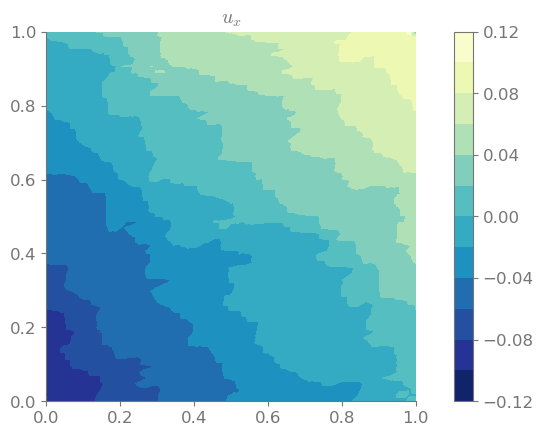

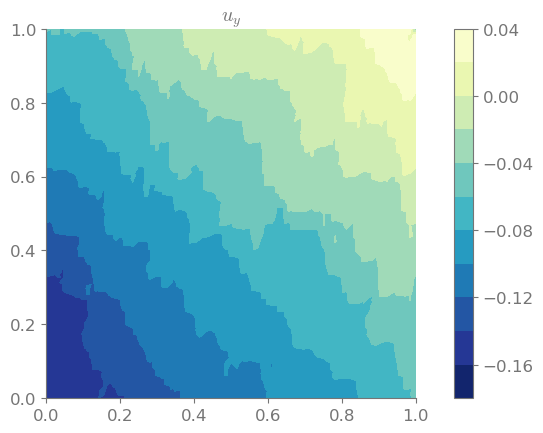

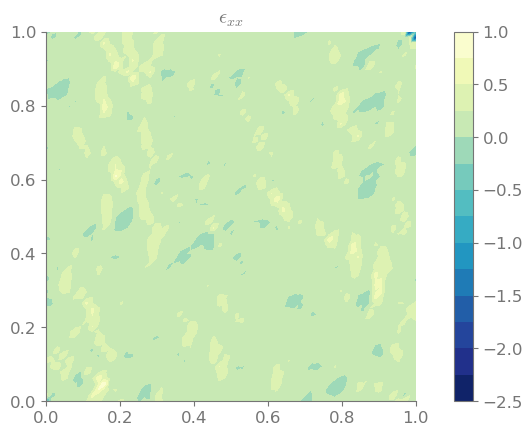

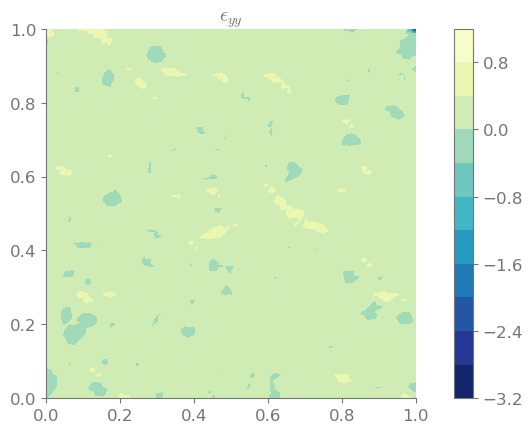

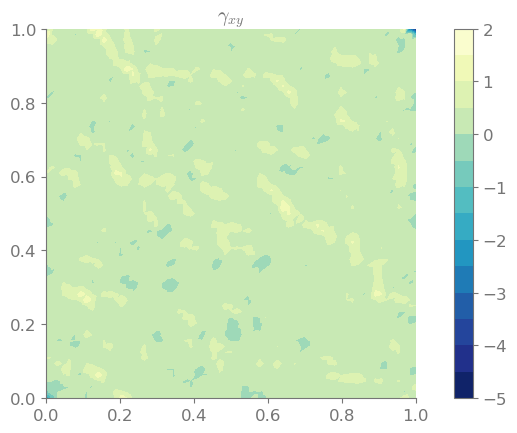

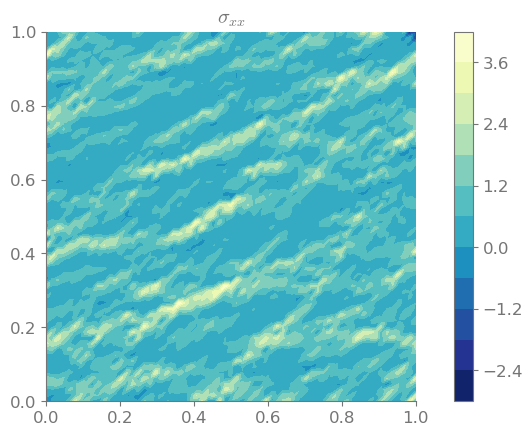

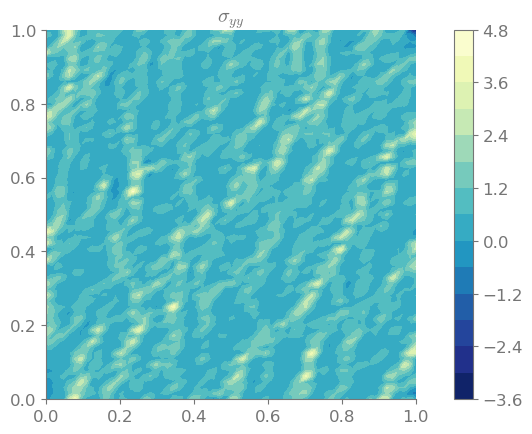

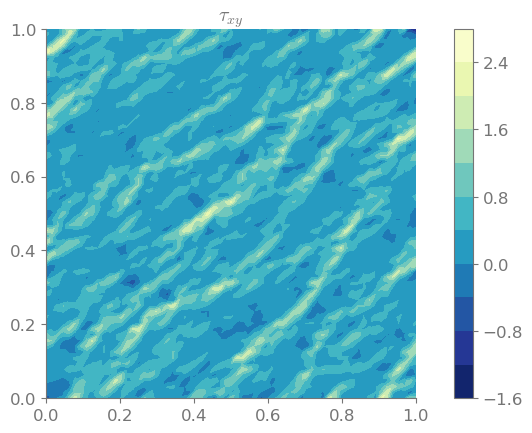

In [154]:
# Post-processing
start_time = datetime.now()
disp_complete = pos.complete_disp(bc_array, nodes, disp)
strain_nodes, stress_nodes = pos.strain_nodes(nodes, elements, mats,
                                            disp_complete)
pos.fields_plot(elements, nodes, disp_complete, E_nodes=strain_nodes,
                S_nodes=stress_nodes)
end_time = datetime.now()
print('Duration for post processing: {}'.format(end_time - start_time))
print('Analysis terminated successfully!')

In [153]:
disp_complete

array([[-0.08225475, -0.14253691],
       [-0.09556387, -0.15947832],
       [-0.0955684 , -0.15989531],
       ...,
       [ 0.09346098,  0.0218379 ],
       [ 0.11471336,  0.03674945],
       [ 0.01774525, -0.04253691]], shape=(4225, 2))